# imports the necessary library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Libraries ready!")

✅ Libraries ready!


# Load All 3 Datasets

In [6]:
from pathlib import Path

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent

nazario     = pd.read_csv(root / 'data' / 'raw' / 'phishing email datasets' / 'Nazario.csv')
nigerian    = pd.read_csv(root / 'data' / 'raw' / 'phishing email datasets' / 'Nigerian_Fraud.csv')
spamassasin = pd.read_csv(root / 'data' / 'raw' / 'phishing email datasets' / 'SpamAssasin.csv')

# Tag the source so we know where each email came from
nazario['source']     = 'Nazario'
nigerian['source']    = 'Nigerian_Fraud'
spamassasin['source'] = 'SpamAssasin'

# Merge all into one
df = pd.concat([nazario, nigerian, spamassasin], ignore_index=True)

print(f"Total emails : {len(df):,}")
print(f"Columns      : {df.columns.tolist()}")

Total emails : 10,706
Columns      : ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label', 'source']


# first look at dataset

In [7]:
df.head()

,sender,receiver,date,subject,body,urls,label,source
0,Mail System Internal Data <MAILER-DAEMON@monke...,NaN,28 Sep 2017 09:57:25 -0400,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA,This text is part of the internal format of yo...,1,1,Nazario
1,cPanel <service@cpanel.com>,jose@monkey.org,"Fri, 30 Oct 2015 00:00:48 -0500",Verify Your Account,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1,1,Nazario
2,Microsoft Outlook <recepcao@unimedceara.com.br>,NaN,"Fri, 30 Oct 2015 06:21:59 -0300 (BRT)",Helpdesk Mailbox Alert!!!,Your two incoming mails were placed on pending...,1,1,Nazario
3,Ann Garcia <AnGarcia@mcoe.org>,"""info@maaaaa.org"" <info@maaaaa.org>","Fri, 30 Oct 2015 14:54:33 +0000",IT-Service Help Desk,Password will expire in 3 days. Click Here To ...,0,1,Nazario
4,"""USAA"" <usaaacctupdate@sccu4u.com>",Recipients <usaaacctupdate@sccu4u.com>,"Fri, 30 Oct 2015 14:02:33 -0500",Final USAA Reminder - Update Your Account Now,"To ensure delivery to your inbox, please add U...",1,1,Nazario


# Check Dataset Shape & Types

In [8]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print()
print("Column data types:")
print(df.dtypes)

Rows    : 10,706
Columns : 8

Column data types:
sender        str
receiver      str
date          str
subject       str
body          str
urls        int64
label       int64
source        str
dtype: object


# Check Missing Values

In [9]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
sender       331
receiver    1630
date         483
subject       59
body           1
urls           0
label          0
source         0
dtype: int64


# Class Distribution

In [10]:
# label: 0 = Legitimate, 1 = Phishing
print("Label counts:")
print(df['label'].value_counts())
print()
print("In percentages:")
print(df['label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Label counts:
label
1    6615
0    4091
Name: count, dtype: int64

In percentages:
label
1    61.8%
0    38.2%
Name: proportion, dtype: str


# Visualize Class Balance

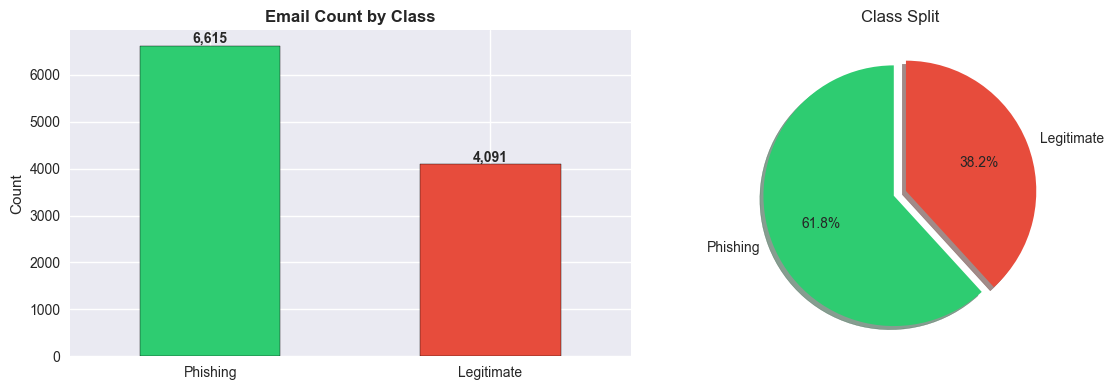

⚠️  Dataset is imbalanced — will handle during model training


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2ecc71', '#e74c3c']
labels = {0: 'Legitimate', 1: 'Phishing'}
df['label_name'] = df['label'].map(labels)

df['label_name'].value_counts().plot(kind='bar', ax=axes[0],
    color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Email Count by Class', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom', fontweight='bold')

df['label_name'].value_counts().plot(kind='pie', ax=axes[1],
    colors=colors, autopct='%1.1f%%', startangle=90,
    explode=(0.05, 0.05), shadow=True)
axes[1].set_title('Class Split'); axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/class_distribution.png', dpi=150)
plt.show()
print("⚠️  Dataset is imbalanced — will handle during model training")

#  Save Exploration Output

In [13]:
from pathlib import Path

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent

processed_dir = root / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

output_file = processed_dir / 'emails_raw_merged.csv'
df.to_csv(output_file, index=False)
print(f"✅ Merged dataset saved → {output_file}")
print("➡️  Move on to Notebook 02: Cleaning & Preprocessing")

✅ Merged dataset saved → c:\Users\Dell\OneDrive\Documents\OneDrive\Desktop\phishing-detection\data\processed\emails_raw_merged.csv
➡️  Move on to Notebook 02: Cleaning & Preprocessing
